In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import locale

In [2]:
data = pd.read_csv('Metro-Systems-Worldwide.csv')

In [3]:
data.head()

,City,Country\r\nregion,Name,Service\r\nopened,Last\r\nexpanded,Stations,System length,Annual ridership\r\n(millions)
0,Algiers,Algeria,Algiers Metro,2011,2018,19,18.5 km (11.5 mi),45.3 (2019)
1,Buenos Aires,Argentina,Buenos Aires Underground,1913,2019,78,56.7 km (35.2 mi),74.0 (2020)
2,Yerevan,Armenia,Yerevan Metro,1981,1996,10,12.1 km (7.5 mi),23.3 (2022)
3,Sydney,Australia,Sydney Metro,2019,–,13,36 km (22 mi),16.3 (2022)
4,Vienna,Austria,Vienna U-Bahn,1978,2017,98,83.3 km (51.8 mi),459.8 (2019)


We gotta rename some of these columns first

In [4]:
mapper1 = {
    "Country\r\nregion":"Country Region",
    "Service\r\nopened":"Service Opened",
    "Last\r\nexpanded":"Last Expanded",
    "Annual ridership\r\n(millions)": "Annual ridership(millions)"
}
data.rename(columns=mapper1,inplace=True)

In [5]:
data

,City,Country Region,Name,Service Opened,Last Expanded,Stations,System length,Annual ridership(millions)
0,Algiers,Algeria,Algiers Metro,2011,2018,19,18.5 km (11.5 mi),45.3 (2019)
1,Buenos Aires,Argentina,Buenos Aires Underground,1913,2019,78,56.7 km (35.2 mi),74.0 (2020)
2,Yerevan,Armenia,Yerevan Metro,1981,1996,10,12.1 km (7.5 mi),23.3 (2022)
3,Sydney,Australia,Sydney Metro,2019,–,13,36 km (22 mi),16.3 (2022)
4,Vienna,Austria,Vienna U-Bahn,1978,2017,98,83.3 km (51.8 mi),459.8 (2019)
...,...,...,...,...,...,...,...,...
200,San Juan,United States,Tren Urbano,2004,2005,16,17.2 km (10.7 mi),2.5 (2022)
201,"Washington, D.C.",United States,Washington Metro,1976,2023,98,206 km (128 mi),93.0 (2022)
202,Tashkent,Uzbekistan,Tashkent Metro,1977,2023,48,59.1 km (36.7 mi),136.7 (2022)
203,Caracas,Venezuela,Caracas Metro,1983,2015,49,67.2 km (41.8 mi),358 (2017)


Now We have 2 tasks: 
1. In system length column, we'll convert it to just numbers and add a column for miles aswell.
2. In annual ridership(millions) column, there's the number of riderships and the year beside it. We'll separate them.

We'll also start working on a copy of a data so that we have access to both unchanged data and the modified one

In [6]:
data1 = data.copy()

In [7]:
data1["System length"] = data1["System length"].apply(lambda x: x.split()[0]).astype("float64")


In [8]:
data1.rename(columns={"System length":"System Length(km)"},inplace=True)

In [9]:
values = data["System length"].apply(lambda x: x.split()[2][1:]).astype("float64")
data1.insert(7,"System Length(miles)",values) 

In [10]:
data1

,City,Country Region,Name,Service Opened,Last Expanded,Stations,System Length(km),System Length(miles),Annual ridership(millions)
0,Algiers,Algeria,Algiers Metro,2011,2018,19,18.5,11.5,45.3 (2019)
1,Buenos Aires,Argentina,Buenos Aires Underground,1913,2019,78,56.7,35.2,74.0 (2020)
2,Yerevan,Armenia,Yerevan Metro,1981,1996,10,12.1,7.5,23.3 (2022)
3,Sydney,Australia,Sydney Metro,2019,–,13,36.0,22.0,16.3 (2022)
4,Vienna,Austria,Vienna U-Bahn,1978,2017,98,83.3,51.8,459.8 (2019)
...,...,...,...,...,...,...,...,...,...
200,San Juan,United States,Tren Urbano,2004,2005,16,17.2,10.7,2.5 (2022)
201,"Washington, D.C.",United States,Washington Metro,1976,2023,98,206.0,128.0,93.0 (2022)
202,Tashkent,Uzbekistan,Tashkent Metro,1977,2023,48,59.1,36.7,136.7 (2022)
203,Caracas,Venezuela,Caracas Metro,1983,2015,49,67.2,41.8,358 (2017)


In [11]:
data['Annual ridership(millions)'].isnull().sum()

16

16 Missing values

In [12]:
data1['Annual ridership(millions)'] = data1['Annual ridership(millions)'].fillna(0)

In [13]:
data1['Annual ridership(millions)'].isnull().sum()

0

Now 0

I found out that not all the value's formats are the same. There are some exceptions. We'll fix them firstly.


In [14]:
filt = data1['Annual ridership(millions)'] == "0.876 (6 days in 2020)"
data1[filt]

filt2 = data1['Annual ridership(millions)'] == "50.7(2018)"
data1[filt2]

,City,Country Region,Name,Service Opened,Last Expanded,Stations,System Length(km),System Length(miles),Annual ridership(millions)
104,Mashhad,Iran,Mashhad Urban Railway,2011,2019,35,37.5,23.3,50.7(2018)


In [15]:
data1.replace("0.876 (6 days in 2020)","0.876 (2020)",inplace= True)
data1.replace("50.7(2018)","50.7 (2018)",inplace= True)

In [16]:
filt = data1['Annual ridership(millions)'] == "0.876 (6 days in 2020)"
data1[filt]

filt2 = data1['Annual ridership(millions)'] == "50.7(2018)"
data1[filt2]

,City,Country Region,Name,Service Opened,Last Expanded,Stations,System Length(km),System Length(miles),Annual ridership(millions)


We changed the formats of the values. There were two of them so I changed it easily

In [17]:
def extract_year(a):
    
    if "(" in str(a):
        return a.split()[1][1:-1]
    
    else:
        return "Missing"

In [18]:
def remove_year(a):
    if "(" in str(a):
        return a.split()[0]
    
    else:
        return a


In [19]:
data1['Year of Ridership'] = data1['Annual ridership(millions)'].apply(extract_year)
data1['Annual ridership(millions)'] = data1['Annual ridership(millions)'].apply(remove_year)

In [20]:
data1

,City,Country Region,Name,Service Opened,Last Expanded,Stations,System Length(km),System Length(miles),Annual ridership(millions),Year of Ridership
0,Algiers,Algeria,Algiers Metro,2011,2018,19,18.5,11.5,45.3,2019
1,Buenos Aires,Argentina,Buenos Aires Underground,1913,2019,78,56.7,35.2,74.0,2020
2,Yerevan,Armenia,Yerevan Metro,1981,1996,10,12.1,7.5,23.3,2022
3,Sydney,Australia,Sydney Metro,2019,–,13,36.0,22.0,16.3,2022
4,Vienna,Austria,Vienna U-Bahn,1978,2017,98,83.3,51.8,459.8,2019
...,...,...,...,...,...,...,...,...,...,...
200,San Juan,United States,Tren Urbano,2004,2005,16,17.2,10.7,2.5,2022
201,"Washington, D.C.",United States,Washington Metro,1976,2023,98,206.0,128.0,93.0,2022
202,Tashkent,Uzbekistan,Tashkent Metro,1977,2023,48,59.1,36.7,136.7,2022
203,Caracas,Venezuela,Caracas Metro,1983,2015,49,67.2,41.8,358,2017


Now our data is clean.Finally We can ask it some questions and answer them for EDA 

In [21]:
data1.columns

Index(['City', 'Country Region', 'Name', 'Service Opened', 'Last Expanded',
       'Stations', 'System Length(km)', 'System Length(miles)',
       'Annual ridership(millions)', 'Year of Ridership'],
      dtype='object')

# Question 1
    Which cities have the largest metro systems in terms of system length (km/miles)?

In [22]:
data1.groupby(by='City')['System Length(km)'].mean().sort_values(ascending=False)

City
Shanghai     795.50
Beijing      785.70
Guangzhou    617.05
Shenzhen     547.42
Chengdu      518.50
              ...  
Catania        8.80
Dnipro         7.80
Genoa          7.10
Karaj          6.50
Lausanne       5.90
Name: System Length(km), Length: 194, dtype: float64

1. Shanghai     795.50
2. Beijing      785.70
3. Guangzhou    617.05
4. Shenzhen     547.42
5. Chengdu      518.50

These cities have the largest metro systems.

# Question 2
    What is the average number of stations in metro systems across different cities?

In [23]:
data1.groupby('Country Region')['Stations'].mean()

Country Region
Algeria            19.000000
Argentina          78.000000
Armenia            10.000000
Australia          13.000000
Austria            98.000000
                     ...    
United Kingdom    110.666667
United States      67.266667
Uzbekistan         48.000000
Venezuela          49.000000
Vietnam            12.000000
Name: Stations, Length: 62, dtype: float64

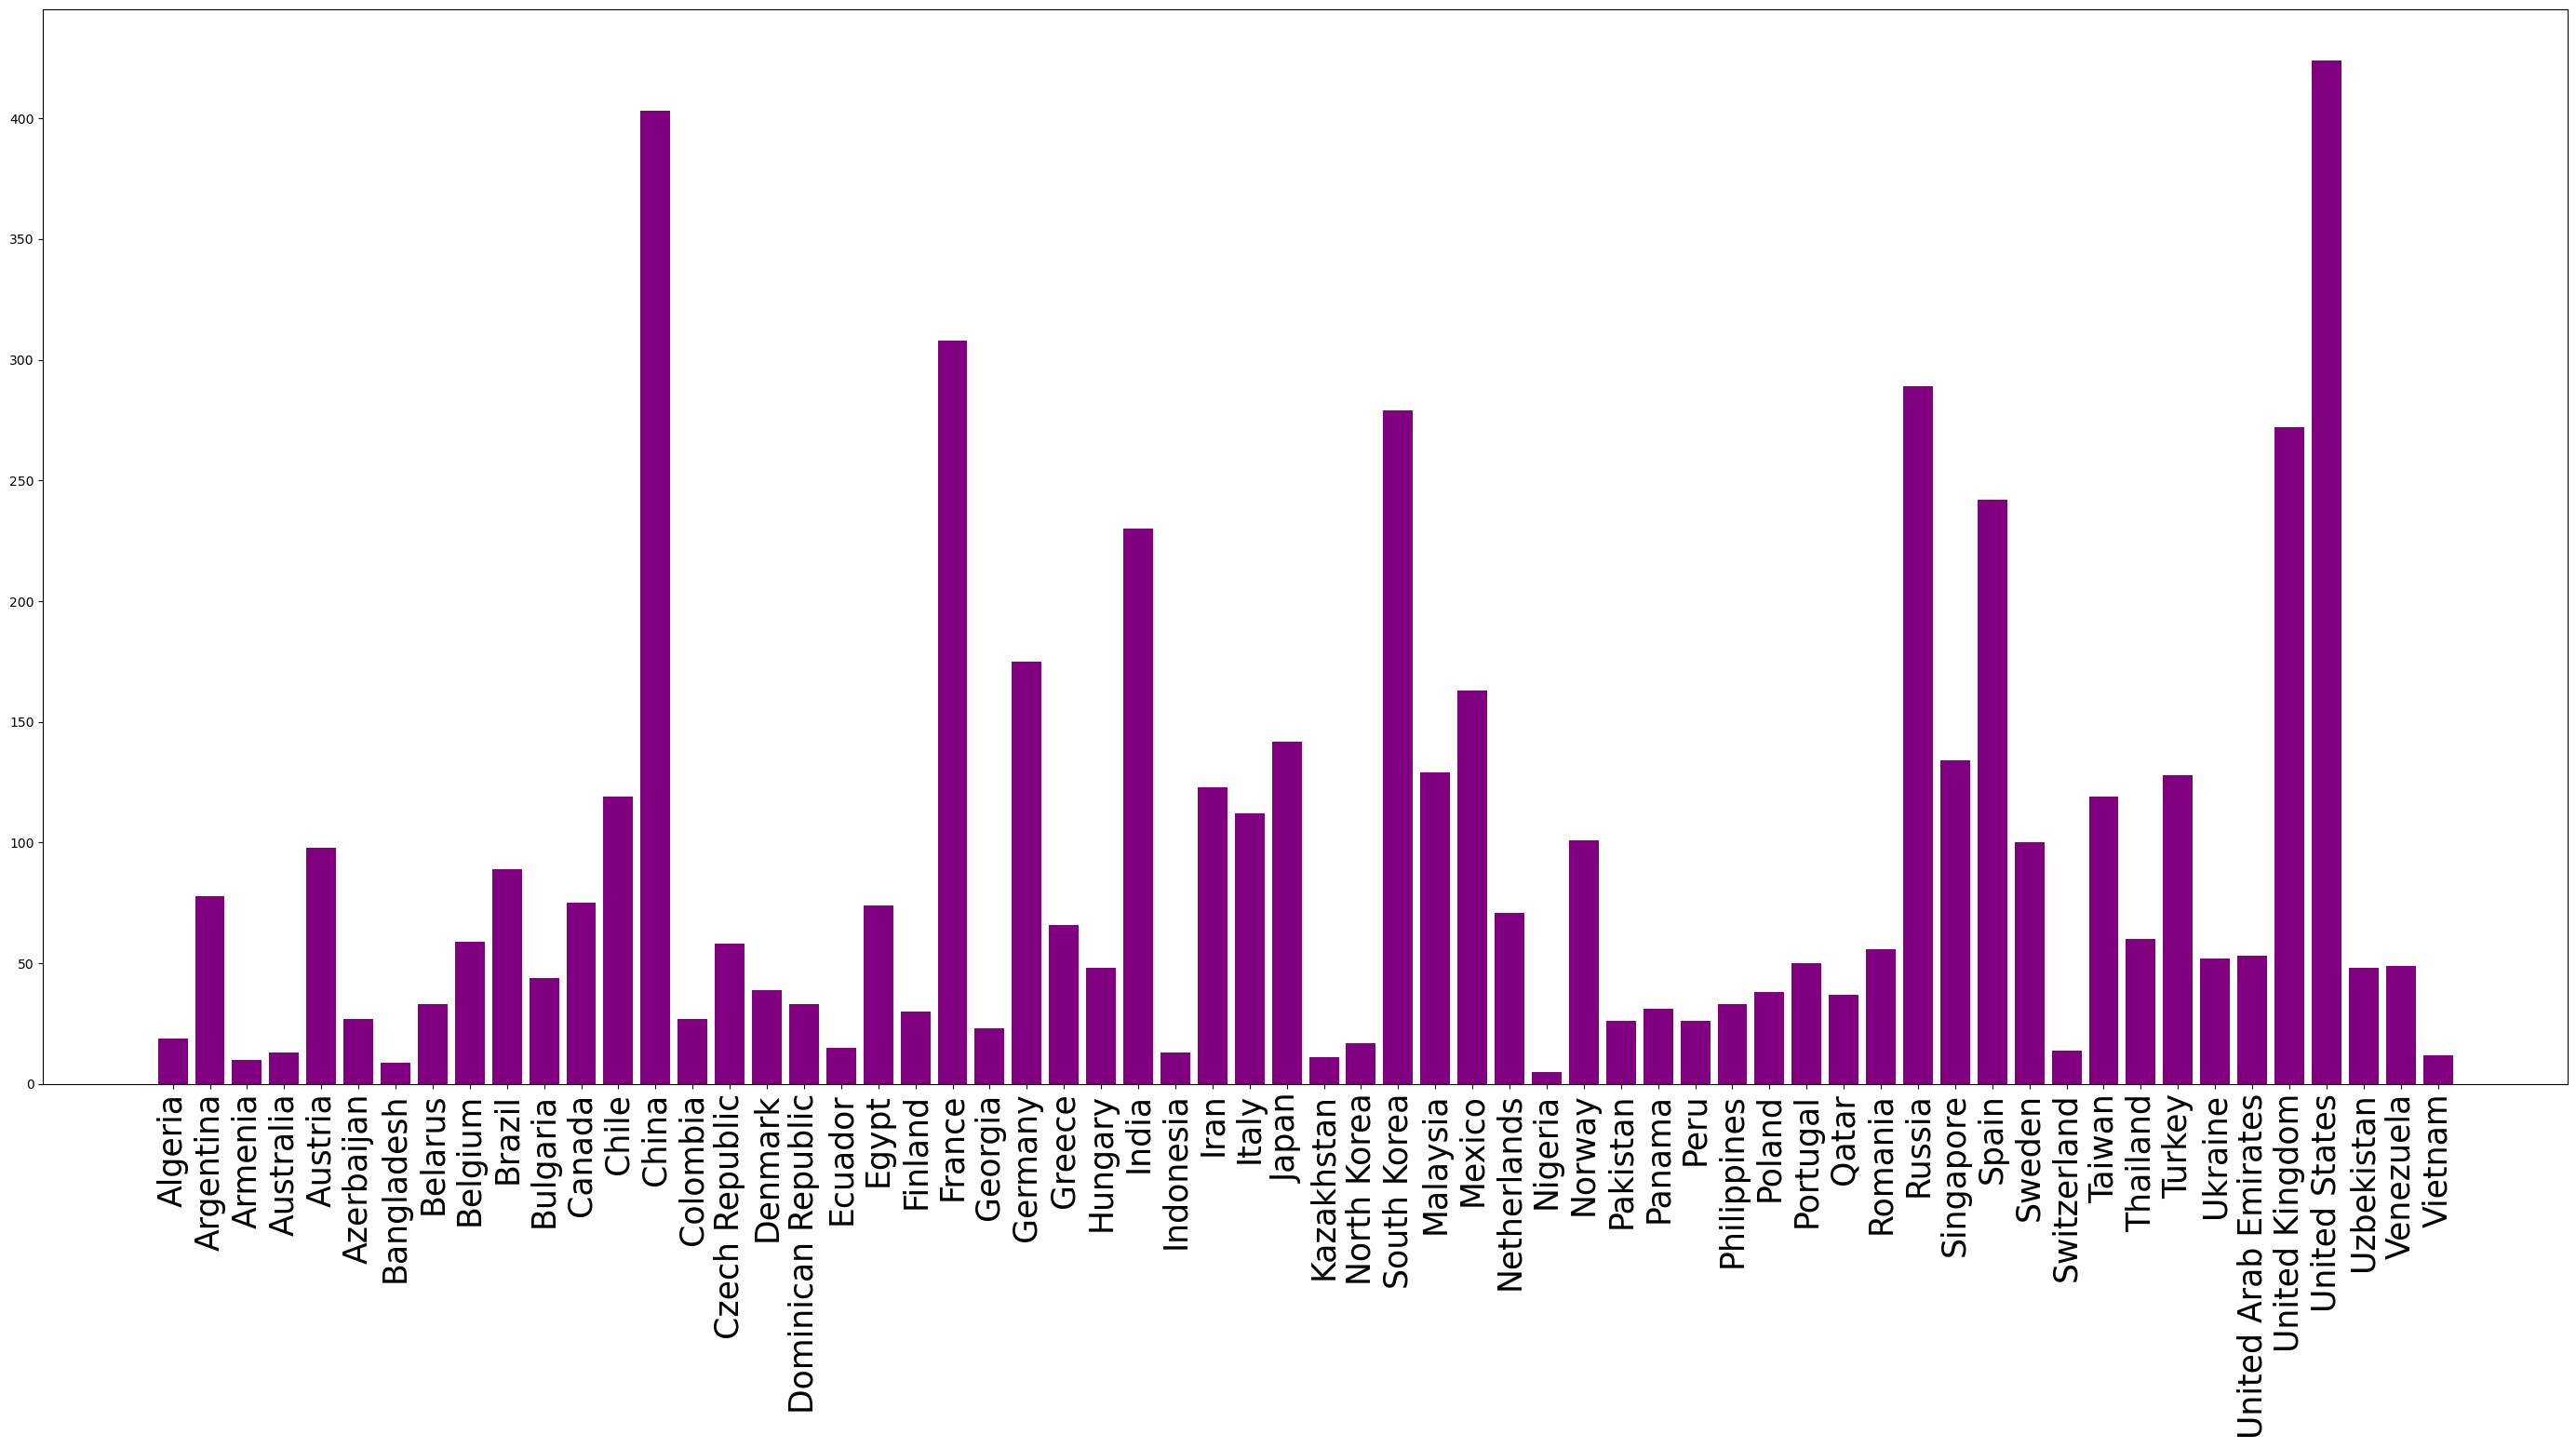

In [24]:
plt.figure(figsize=[35,15])
plt.bar(x=data1['Country Region'],height=data1['Stations'],color='purple')

plt.xticks(fontsize=25)
plt.xticks(rotation=90);


In [25]:
data1['Country Region'].unique()[:30]

array(['Algeria', 'Argentina', 'Armenia', 'Australia', 'Austria',
       'Azerbaijan', 'Bangladesh', 'Belarus', 'Belgium', 'Brazil',
       'Bulgaria', 'Canada', 'Chile', 'China', 'Colombia',
       'Czech Republic', 'Denmark', 'Dominican Republic', 'Ecuador',
       'Egypt', 'Finland', 'France', 'Georgia', 'Germany', 'Greece',
       'Hungary', 'India', 'Indonesia', 'Iran', 'Italy'], dtype=object)

# Question 3 
    Which country/region has the highest annual ridership among all the metro systems?

In [26]:
data1['Annual ridership(millions)'] = data1['Annual ridership(millions)'].apply(lambda x: str(x).replace(',',''))
data1['Annual ridership(millions)'] = data1['Annual ridership(millions)'].astype('float64')

In [27]:
data1.groupby('Country Region')['Annual ridership(millions)'].mean().sort_values(ascending=False)

Country Region
Egypt         1314.000000
Singapore      766.500000
Japan          498.876923
China          460.362133
Austria        459.800000
                 ...     
Vietnam          7.500000
Qatar            0.000000
Nigeria          0.000000
Ecuador          0.000000
Bangladesh       0.000000
Name: Annual ridership(millions), Length: 62, dtype: float64

Egypt has the highes annual ridership among all the metro systems with 1314 Million

# Question 4
    How many metro systems were opened for service in the last five years?

In [28]:
data1.groupby(data1[data["Service Opened"] >= 2018]['Service Opened']).value_counts().sum()

28

## Complex Questions 
    

# Question 5
    Can you identify any correlations between the system length (in kilometers) and annual ridership (in millions) of metro systems across different cities? Is there a trend indicating that longer systems attract higher ridership?

In [29]:
data1['Annual ridership(millions)'].corr(data1['System Length(km)'])

0.808263986217301

Correlation betweeen annual ridership and system length is 0.8 which is very high. This means that longer systems attract higher ridership in overall stats.

# Question 6
    Are there any notable outliers in the dataset in terms of annual ridership? Can you identify cities with unusually high or low ridership and explore potential factors contributing to these values?

In [30]:
ar = 'Annual ridership(millions)'
data1[(data1[ar] < 10) & (data1[ar] > 0)][['Country Region','City',ar]][:10].sort_values(by=ar)

,Country Region,City,Annual ridership(millions)
87,India,Ahmedabad,0.400
56,China,Taiyuan,0.876
188,United States,Baltimore,2.000
99,India,Nagpur,4.000
100,India,Noida,5.000
110,Italy,Catania,5.800
93,India,Jaipur,7.000
60,China,Wenzhou,7.010
180,Ukraine,Dnipro,7.500
39,China,Jinan,8.680


These Cities has the least Annual Ridership stats among all cities. To spot some unusual values we have to look at the other cities stats on the countries. For example we can look at India's stats to check if there's something unusual about city 'Ahmedabad'.

In [31]:
data1[(data1['Country Region'] == 'India') & (data1[ar] != 0)][['City', ar]].sort_values(by=ar,ascending=True)

,City,Annual ridership(millions)
87,Ahmedabad,0.40
99,Nagpur,4.00
100,Noida,5.00
93,Jaipur,7.00
95,Kochi,17.00
91,Gurgaon,18.30
97,Lucknow,22.00
89,Chennai,42.00
98,Mumbai,126.00
92,Hyderabad,173.00


I noticed somethin unusual about the city ahmedabad. After a quick research I found that it was the fifth most populated city in India. Howewer annual ridership was the lowest in the whole dataset

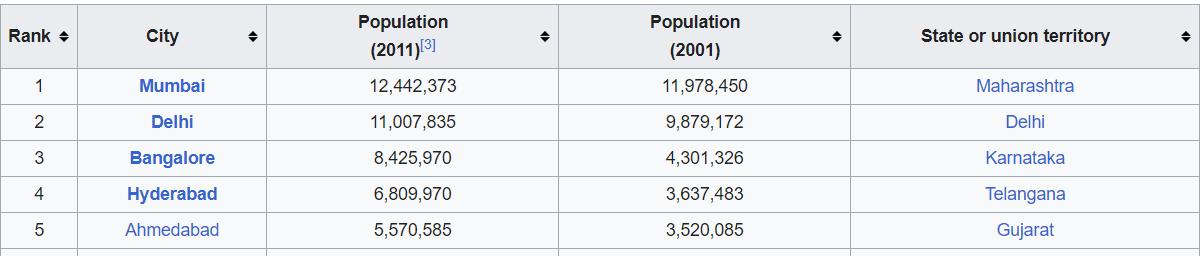

To get deep into this information. We have to get the year of the data.

In [32]:
data1[data1['City'] == 'Ahmedabad']['Year of Ridership']

87    2021
Name: Year of Ridership, dtype: object

It was the annual ridership of year 2021. I suppose it is because of 2019 covid pandemic.